In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm
from windrose import WindroseAxes
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

## DPW Supervised Learning

In [2]:
dpw_final = pd.read_csv("final PM data/dpw_final_pm25.csv")
dpw_final = dpw_final.sort_values("datetime_utc").reset_index(drop=True)
dpw_final.head()

,datetime_utc,rh,temp,pm25,ws,wd,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,58.840000,4.361667,0.494283,9.30,270.0,9.300000,1.708382e-15,6,1.000000,6.123234e-17,0.399550,0.464817,0.442483,0.841567,0
1,2025-01-02 07:00:00+00:00,55.430000,4.113333,0.694683,5.60,260.0,5.514923,9.724298e-01,7,0.965926,-2.588190e-01,0.494283,0.399550,0.464817,0.478867,0
2,2025-01-02 08:00:00+00:00,52.586667,3.908333,0.886617,5.70,280.0,5.613404,-9.897946e-01,8,0.866025,-5.000000e-01,0.694683,0.494283,0.399550,0.458833,0
3,2025-01-02 09:00:00+00:00,50.208333,3.943333,0.952167,7.20,290.0,6.765787,-2.462545e+00,9,0.707107,-7.071068e-01,0.886617,0.694683,0.494283,0.442483,0
4,2025-01-02 10:00:00+00:00,49.291667,4.011667,0.969433,4.45,260.0,4.382395,7.727344e-01,10,0.500000,-8.660254e-01,0.952167,0.886617,0.694683,0.464817,0


In [ ]:
#define 7 hour gap so as to not "leak" data between train/validation/testing
gap = 7
n = len(dpw_final)

#we segment full time series data into train/valid/test sets quarterly with proper gaps
#allows proper spread of data so that train/valid/test are not limited to certain areas in the time series
train_size = int(.15 * n)
val_size = int(.05 * n)
test_size = int(.05 * n)

#lists of dataframes
train_dfs = []
val_dfs = []
test_dfs = []
start = 0

#loop through data 4 times
for i in range(4):
    train_start = start
    train_end = train_start + train_size

    val_start = train_end + gap
    val_end = val_start + val_size

    test_start = val_end + gap
    test_end = test_start + test_size

    #break loop if out of data
    if test_end > n:
        break

    #add dataframes to list
    train_dfs.append(dpw_final.iloc[train_start:train_end])
    val_dfs.append(dpw_final.iloc[val_start:val_end])
    test_dfs.append(dpw_final.iloc[test_start:test_end])

    #define new "start"
    start = test_end + gap

#concatenate full dataframe
train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

features = [
    "wind_u", "wind_v",
    "pm_lag6", "pm_lag3", "pm_lag2", "pm_lag1",
    "hour_sin", "hour_cos",
    "rh"
]

#define train, test, validation arrays
X_train = train_df[features].values
Y_train = train_df["pm25_bin"].values

X_val = val_df[features].values
Y_val = val_df["pm25_bin"].values

X_test = test_df[features].values
Y_test = test_df["pm25_bin"].values

#create tensor objects
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_val = torch.tensor(Y_val, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [4]:
input_dim = len(features)
torch.manual_seed(8)
#define neural network
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
        )
    
    def forward(self, x):
        return self.model(x)

model = NN()

#utilize cross entropy loss here
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [5]:
#epochs based on observation of validation accuracy
epochs = 1000

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = loss_function(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    #calculate validation accuracy
    with torch.no_grad():
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == Y_val).float().mean()

    #print to check validation accuracy
    if (epoch) % 100 == 0:
        epoch_s = "Epoch: " + str(epoch) + " "
        loss_s = "Loss: " + str(loss.item()) + " "
        valid_s = "Validation Accuracy: " + str(float(val_accuracy))
        print(epoch_s + loss_s + valid_s)

Epoch: 0 Loss: 4.921516418457031 Validation Accuracy: 0.31165310740470886
Epoch: 100 Loss: 1.196157693862915 Validation Accuracy: 0.39566394686698914
Epoch: 200 Loss: 0.960504949092865 Validation Accuracy: 0.5474254488945007
Epoch: 300 Loss: 0.8757444024085999 Validation Accuracy: 0.577235758304596
Epoch: 400 Loss: 0.8053378462791443 Validation Accuracy: 0.6192411780357361
Epoch: 500 Loss: 0.7485364079475403 Validation Accuracy: 0.6463414430618286
Epoch: 600 Loss: 0.7099888920783997 Validation Accuracy: 0.6666666865348816
Epoch: 700 Loss: 0.6836002469062805 Validation Accuracy: 0.6937669515609741
Epoch: 800 Loss: 0.6641641855239868 Validation Accuracy: 0.696476936340332
Epoch: 900 Loss: 0.6507730484008789 Validation Accuracy: 0.7046070694923401


In [6]:
test_outputs = model(X_test)
#select bin with highest probability
test_preds = torch.argmax(test_outputs, dim=1)

test_acc = (test_preds == Y_test).float().mean()
print("Final Test Accuracy " + str(test_acc.item()))

Final Test Accuracy 0.7411924004554749


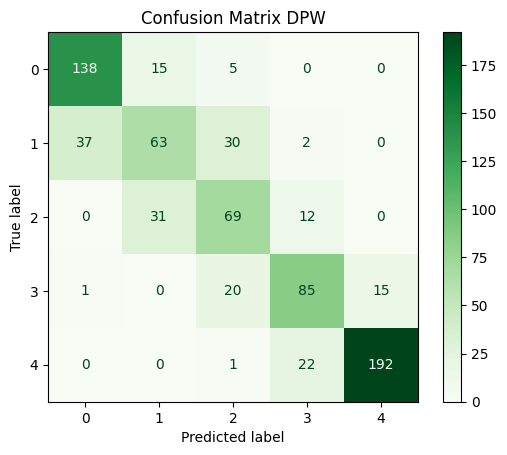

In [7]:
#create confusion matrix for outputs
cm = confusion_matrix(Y_test.numpy(), test_preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix DPW")

plt.savefig("supervised plots/DPW confusion matrix.png")
plt.show()

In [8]:
#produce precision, recall and f1 scores for each bin
print(classification_report(Y_test.numpy(), test_preds.numpy()))

              precision    recall  f1-score   support

           0       0.78      0.87      0.83       158
           1       0.58      0.48      0.52       132
           2       0.55      0.62      0.58       112
           3       0.70      0.70      0.70       121
           4       0.93      0.89      0.91       215

    accuracy                           0.74       738
   macro avg       0.71      0.71      0.71       738
weighted avg       0.74      0.74      0.74       738



In [9]:
#function that randomly permutates one feature and measures drop off in model performance
def permutation_importance(model, X, y):
    model.eval()
    
    #evaluate baseline accuracy
    with torch.no_grad():
        baseline_preds = torch.argmax(model(X), dim=1)
        baseline_accuracy = (baseline_preds == y).float().mean()
    
    accuracy_differences = []
    
    for i in range(X.shape[1]):
        X_permuted = X.clone()
        
        #shuffle feature and run model
        idx = torch.randperm(X.shape[0])
        X_permuted[:, i] = X_permuted[idx, i]
        
        with torch.no_grad():
            preds = torch.argmax(model(X_permuted), dim=1)
            accuracy = (preds == y).float().mean()
        
        accuracy_difference = baseline_accuracy - accuracy
        accuracy_differences.append(accuracy_difference.item())
    
    return accuracy_differences

accuracy_differences = permutation_importance(model, X_test, Y_test)

for f, acc_d in zip(features, accuracy_differences):
    print(f, acc_d)

wind_u 0.010840117931365967
wind_v 0.008130073547363281
ws -0.005420088768005371
pm_lag6 -0.012195110321044922
pm_lag3 0.012195110321044922
pm_lag2 0.07452571392059326
pm_lag1 0.5406503677368164
hour_sin -0.006775081157684326
hour_cos 0.004065036773681641
rh 0.004065036773681641


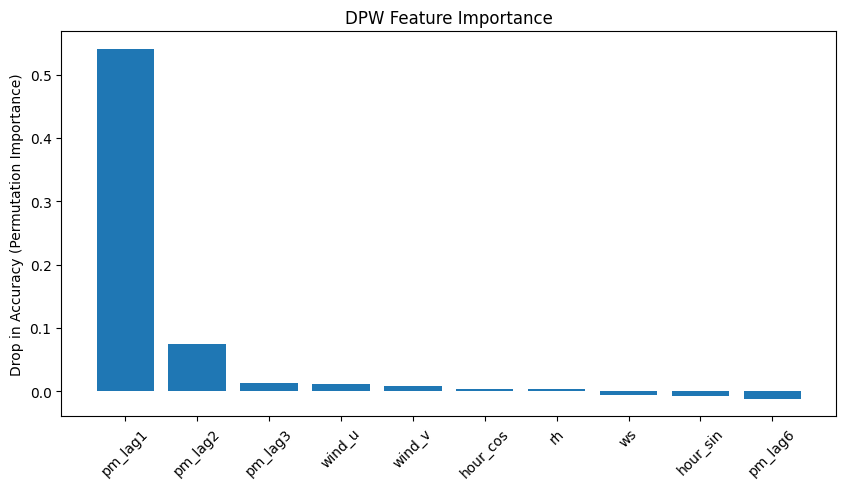

In [10]:
#plot feature importance
importance_dict = dict(zip(features, accuracy_differences))
sorted_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("DPW Feature Importance")

plt.savefig("supervised plots/DPW feature importance full.png")
plt.show()

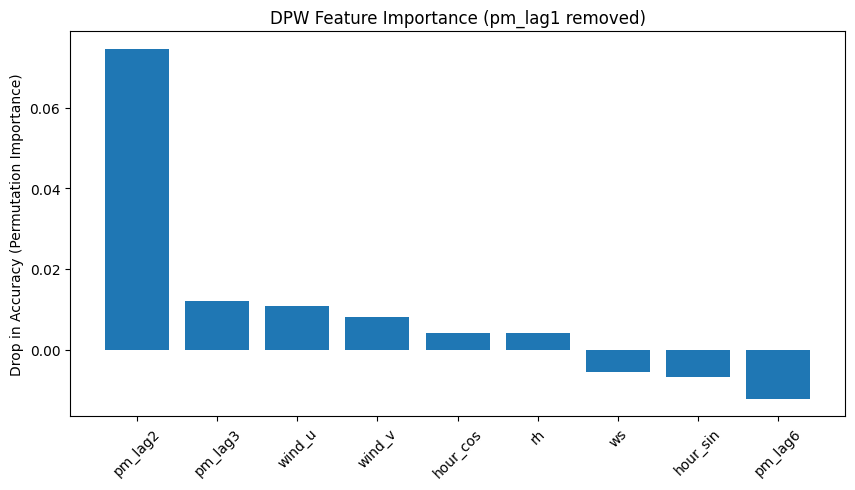

In [11]:
importance_dict = dict(zip(features, accuracy_differences))
#remove pm_lag1 to see other features better
sorted_items = sorted([(f, v) for f, v in importance_dict.items() if f != "pm_lag1"], key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("DPW Feature Importance (pm_lag1 removed)")

plt.savefig("supervised plots/DPW feature importance pm_lag1 removed.png")
plt.show()

## PEMA Supervised Learning

In [12]:
pema_final = pd.read_csv("final PM data/pema_final_pm25.csv")
pema_final = pema_final.sort_values("datetime_utc").reset_index(drop=True)
pema_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,61.271667,3.978333,288.680000,4.513833,0.045150,4.276054,-1.445701,6,1.000000,6.123234e-17,0.040767,0.049150,0.033750,0.096833,0
1,2025-01-02 07:00:00+00:00,57.641667,3.725000,289.245000,5.204833,0.052300,4.913976,-1.715556,7,0.965926,-2.588190e-01,0.045150,0.040767,0.049150,0.050633,0
2,2025-01-02 08:00:00+00:00,53.136667,3.656667,294.898333,5.591833,0.052267,5.072107,-2.354215,8,0.866025,-5.000000e-01,0.052300,0.045150,0.040767,0.047417,0
3,2025-01-02 09:00:00+00:00,50.996667,3.491667,291.131667,4.624833,0.054683,4.313834,-1.667310,9,0.707107,-7.071068e-01,0.052267,0.052300,0.045150,0.033750,0
4,2025-01-02 10:00:00+00:00,50.645000,3.486667,284.775000,4.678333,0.061867,4.523643,-1.193087,10,0.500000,-8.660254e-01,0.054683,0.052267,0.052300,0.049150,0


In [13]:
#define 7 hour gap so as to not "leak" data between train/validation/testing
gap = 7
n = len(pema_final)

#we segment full time series data into train/valid/test sets quarterly with proper gaps
#allows proper spread of data so that train/valid/test are not limited to certain areas in the time series
train_size = int(.15 * n)
val_size = int(.05 * n)
test_size = int(.05 * n)

#lists of dataframes
train_dfs = []
val_dfs = []
test_dfs = []
start = 0

#loop through data 4 times
for i in range(4):
    train_start = start
    train_end = train_start + train_size

    val_start = train_end + gap
    val_end = val_start + val_size

    test_start = val_end + gap
    test_end = test_start + test_size

    #break loop if out of data
    if test_end > n:
        break

    #add dataframes to list
    train_dfs.append(pema_final.iloc[train_start:train_end])
    val_dfs.append(pema_final.iloc[val_start:val_end])
    test_dfs.append(pema_final.iloc[test_start:test_end])

    #define new "start"
    start = test_end + gap

#concatenate full dataframe
train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

features = [
    "wind_u", "wind_v",
    "pm_lag6", "pm_lag3", "pm_lag2", "pm_lag1",
    "hour_sin", "hour_cos",
    "rh"
]

#define train, test, validation arrays
X_train = train_df[features].values
Y_train = train_df["pm25_bin"].values

X_val = val_df[features].values
Y_val = val_df["pm25_bin"].values

X_test = test_df[features].values
Y_test = test_df["pm25_bin"].values

#create tensor objects
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_val = torch.tensor(Y_val, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [14]:
input_dim = len(features)

#define neural network
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
        )
    
    def forward(self, x):
        return self.model(x)

model = NN()

#utilize cross entropy loss here
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [15]:
#epochs based on observation of validation accuracy
epochs = 1000

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = loss_function(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    #calculate validation accuracy
    with torch.no_grad():
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == Y_val).float().mean()

    #print to check validation accuracy
    if (epoch) % 100 == 0:
        epoch_s = "Epoch: " + str(epoch) + " "
        loss_s = "Loss: " + str(loss.item()) + " "
        valid_s = "Validation Accuracy: " + str(float(val_accuracy))
        print(epoch_s + loss_s + valid_s)

Epoch: 0 Loss: 2.0850024223327637 Validation Accuracy: 0.03030303120613098
Epoch: 100 Loss: 1.0004246234893799 Validation Accuracy: 0.469696968793869
Epoch: 200 Loss: 0.7970352172851562 Validation Accuracy: 0.5439394116401672
Epoch: 300 Loss: 0.7023976445198059 Validation Accuracy: 0.6136363744735718
Epoch: 400 Loss: 0.6364509463310242 Validation Accuracy: 0.6590909361839294
Epoch: 500 Loss: 0.5878657102584839 Validation Accuracy: 0.7075757384300232
Epoch: 600 Loss: 0.5573134422302246 Validation Accuracy: 0.7181817889213562
Epoch: 700 Loss: 0.5398420691490173 Validation Accuracy: 0.7257575988769531
Epoch: 800 Loss: 0.5273692607879639 Validation Accuracy: 0.728787899017334
Epoch: 900 Loss: 0.5181776881217957 Validation Accuracy: 0.7181817889213562


In [16]:
test_outputs = model(X_test)
#select bin with highest probability
test_preds = torch.argmax(test_outputs, dim=1)

test_acc = (test_preds == Y_test).float().mean()
print("Final Test Accuracy " + str(test_acc.item()))

Final Test Accuracy 0.6954545378684998


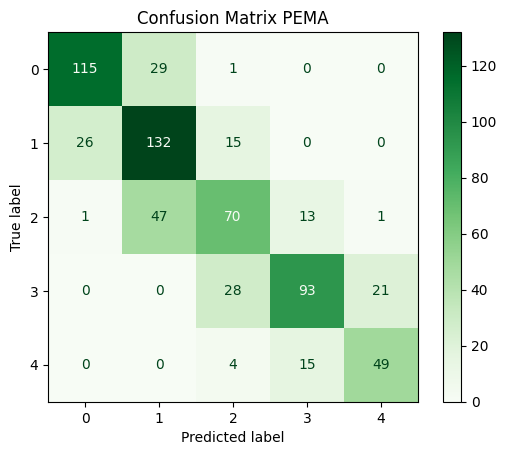

In [17]:
#create confusion matrix for outputs
cm = confusion_matrix(Y_test.numpy(), test_preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix PEMA")

plt.savefig("supervised plots/PEMA confusion matrix.png")
plt.show()

In [18]:
#produce precision, recall and f1 scores for each bin
print(classification_report(Y_test.numpy(), test_preds.numpy()))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       145
           1       0.63      0.76      0.69       173
           2       0.59      0.53      0.56       132
           3       0.77      0.65      0.71       142
           4       0.69      0.72      0.71        68

    accuracy                           0.70       660
   macro avg       0.70      0.69      0.69       660
weighted avg       0.70      0.70      0.69       660



In [19]:
accuracy_differences = permutation_importance(model, X_test, Y_test)

for f, acc_d in zip(features, accuracy_differences):
    print(f, acc_d)

wind_u 0.0
wind_v 0.04242426156997681
pm_lag6 -0.02575761079788208
pm_lag3 0.03939396142959595
pm_lag2 0.050000011920928955
pm_lag1 0.4727272689342499
hour_sin 0.0075757503509521484
hour_cos 0.0030303001403808594
rh -0.0030303001403808594


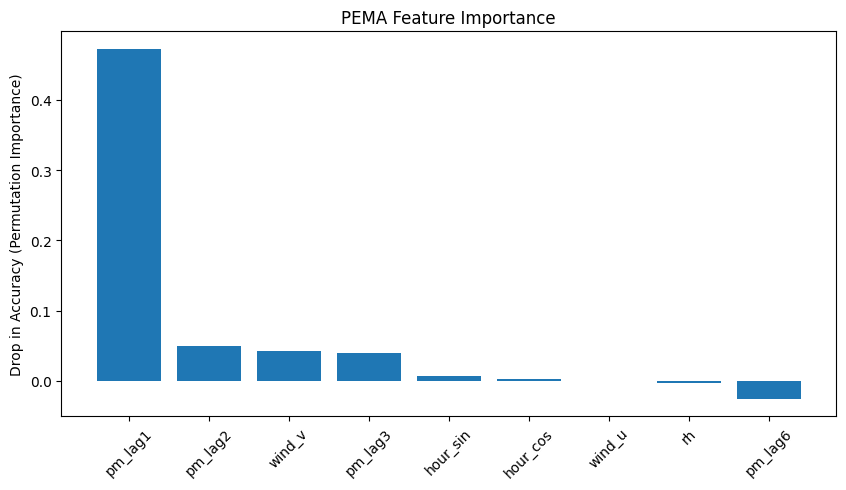

In [20]:
#plot feature importance
importance_dict = dict(zip(features, accuracy_differences))
sorted_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("PEMA Feature Importance")

plt.savefig("supervised plots/PEMA feature importance full.png")
plt.show()

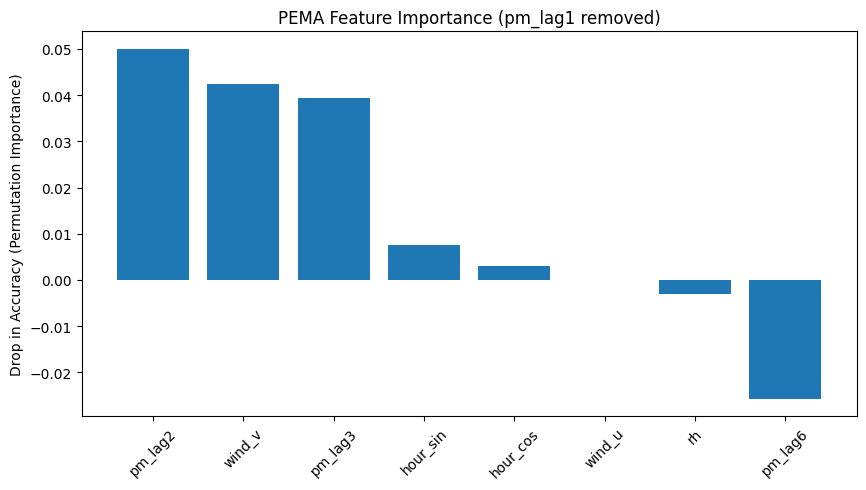

In [21]:
importance_dict = dict(zip(features, accuracy_differences))
#remove pm_lag1 to see other features better
sorted_items = sorted([(f, v) for f, v in importance_dict.items() if f != "pm_lag1"], key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("PEMA Feature Importance (pm_lag1 removed)")

plt.savefig("supervised plots/PEMA feature importance pm_lag1 removed.png")
plt.show()

## PHA Supervised Learning

In [22]:
pha_final = pd.read_csv("final PM data/pha_final_pm25.csv")
pha_final = pha_final.sort_values("datetime_utc").reset_index(drop=True)
pha_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,62.023333,3.330000,261.698333,2.648500,0.207967,2.620748,0.382404,6,1.000000,6.123234e-17,0.165667,0.168467,0.198267,0.389583,0
1,2025-01-02 07:00:00+00:00,58.768333,3.020000,270.975000,2.878667,0.295167,2.878250,-0.048984,7,0.965926,-2.588190e-01,0.207967,0.165667,0.168467,0.214200,0
2,2025-01-02 08:00:00+00:00,55.421667,2.898333,273.275000,2.903833,0.309267,2.899091,-0.165891,8,0.866025,-5.000000e-01,0.295167,0.207967,0.165667,0.192533,0
3,2025-01-02 09:00:00+00:00,53.240000,2.845000,273.426667,2.866000,0.312800,2.860876,-0.171304,9,0.707107,-7.071068e-01,0.309267,0.295167,0.207967,0.198267,0
4,2025-01-02 10:00:00+00:00,52.566667,2.850000,266.546667,2.758667,0.346200,2.753657,0.166170,10,0.500000,-8.660254e-01,0.312800,0.309267,0.295167,0.168467,0


In [23]:
#define 7 hour gap so as to not "leak" data between train/validation/testing
gap = 7
n = len(dpw_final)

#we segment full time series data into train/valid/test sets quarterly with proper gaps
#allows proper spread of data so that train/valid/test are not limited to certain areas in the time series
train_size = int(.15 * n)
val_size = int(.05 * n)
test_size = int(.05 * n)

#lists of dataframes
train_dfs = []
val_dfs = []
test_dfs = []
start = 0

#loop through data 4 times
for i in range(4):
    train_start = start
    train_end = train_start + train_size

    val_start = train_end + gap
    val_end = val_start + val_size

    test_start = val_end + gap
    test_end = test_start + test_size

    #break loop if out of data
    if test_end > n:
        break

    #add dataframes to list
    train_dfs.append(pha_final.iloc[train_start:train_end])
    val_dfs.append(pha_final.iloc[val_start:val_end])
    test_dfs.append(pha_final.iloc[test_start:test_end])

    #define new "start"
    start = test_end + gap

#concatenate full dataframe
train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

features = [
    "wind_u", "wind_v",
    "pm_lag6", "pm_lag3", "pm_lag2", "pm_lag1",
    "hour_sin", "hour_cos",
    "rh"
]

#define train, test, validation arrays
X_train = train_df[features].values
Y_train = train_df["pm25_bin"].values

X_val = val_df[features].values
Y_val = val_df["pm25_bin"].values

X_test = test_df[features].values
Y_test = test_df["pm25_bin"].values

#create tensor objects
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_val = torch.tensor(Y_val, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [24]:
input_dim = len(features)

#define neural network
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
        )
    
    def forward(self, x):
        return self.model(x)

model = NN()

#utilize cross entropy loss here
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [25]:
#epochs based on observation of validation accuracy
epochs = 1000

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = loss_function(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    #calculate validation accuracy
    with torch.no_grad():
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == Y_val).float().mean()

    #print to check validation accuracy
    if (epoch) % 100 == 0:
        epoch_s = "Epoch: " + str(epoch) + " "
        loss_s = "Loss: " + str(loss.item()) + " "
        valid_s = "Validation Accuracy: " + str(float(val_accuracy))
        print(epoch_s + loss_s + valid_s)

Epoch: 0 Loss: 2.8077425956726074 Validation Accuracy: 0.22628726065158844
Epoch: 100 Loss: 1.1967536211013794 Validation Accuracy: 0.4322493076324463
Epoch: 200 Loss: 0.9449774026870728 Validation Accuracy: 0.5528455376625061
Epoch: 300 Loss: 0.8128882646560669 Validation Accuracy: 0.6124660968780518
Epoch: 400 Loss: 0.716769814491272 Validation Accuracy: 0.6544715166091919
Epoch: 500 Loss: 0.659850001335144 Validation Accuracy: 0.6924118995666504
Epoch: 600 Loss: 0.6243488192558289 Validation Accuracy: 0.7249322533607483
Epoch: 700 Loss: 0.5980604290962219 Validation Accuracy: 0.7466124892234802
Epoch: 800 Loss: 0.5768466591835022 Validation Accuracy: 0.7533875107765198
Epoch: 900 Loss: 0.5583308935165405 Validation Accuracy: 0.7750677466392517


In [26]:
test_outputs = model(X_test)
#select bin with highest probability
test_preds = torch.argmax(test_outputs, dim=1)

test_acc = (test_preds == Y_test).float().mean()
print("Final Test Accuracy " + str(test_acc.item()))

Final Test Accuracy 0.7669376730918884


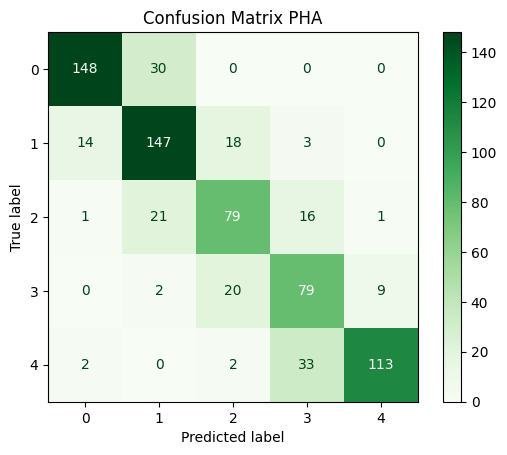

In [27]:
#create confusion matrix for outputs
cm = confusion_matrix(Y_test.numpy(), test_preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix PHA")

plt.savefig("supervised plots/PHA confusion matrix.png")
plt.show()

In [28]:
#produce precision, recall and f1 scores for each bin
print(classification_report(Y_test.numpy(), test_preds.numpy()))

              precision    recall  f1-score   support

           0       0.90      0.83      0.86       178
           1       0.73      0.81      0.77       182
           2       0.66      0.67      0.67       118
           3       0.60      0.72      0.66       110
           4       0.92      0.75      0.83       150

    accuracy                           0.77       738
   macro avg       0.76      0.76      0.76       738
weighted avg       0.78      0.77      0.77       738



In [29]:
accuracy_differences = permutation_importance(model, X_test, Y_test)

for f, acc_d in zip(features, accuracy_differences):
    print(f, acc_d)

wind_u 0.024390220642089844
wind_v -0.0027100443840026855
pm_lag6 -0.004065036773681641
pm_lag3 0.04065042734146118
pm_lag2 0.06910568475723267
pm_lag1 0.5704606771469116
hour_sin 0.001354992389678955
hour_cos 0.001354992389678955
rh 0.005420029163360596


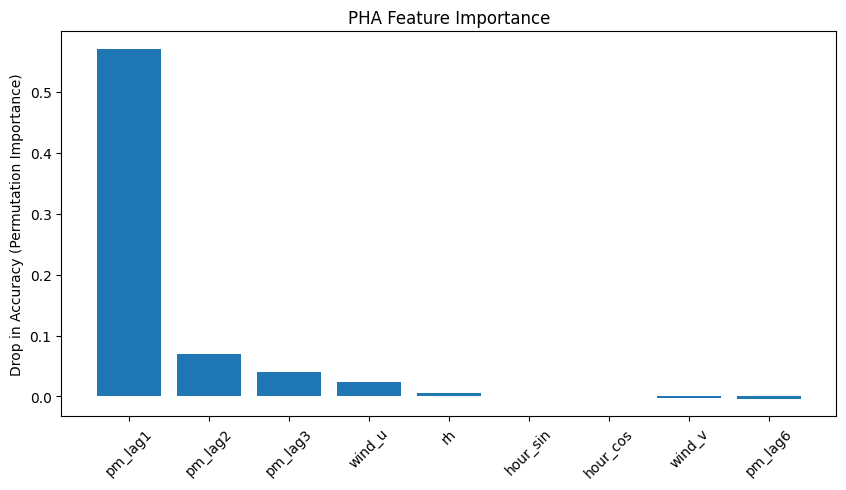

In [30]:
#plot importance values on bar chart
importance_dict = dict(zip(features, accuracy_differences))
sorted_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("PHA Feature Importance")

plt.savefig("supervised plots/PHA feature importance full.png")
plt.show()

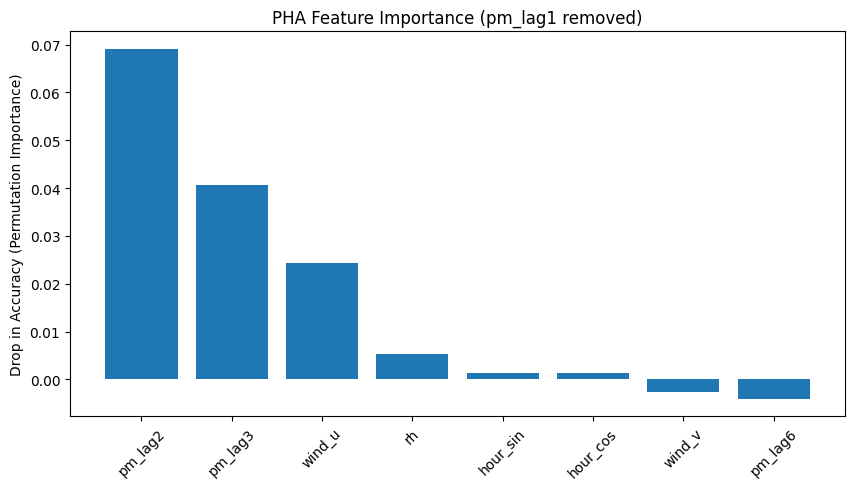

In [31]:
importance_dict = dict(zip(features, accuracy_differences))
#remove pm_lag1 to see other features better
sorted_items = sorted([(f, v) for f, v in importance_dict.items() if f != "pm_lag1"], key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("PHA Feature Importance (pm_lag1 removed)")

plt.savefig("supervised plots/PHA feature importance pm_lag1 removed.png")
plt.show()